In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_sweep_data(sweep_dir):
    """
    Load simulation sweep data from a directory of epsilon experiments.
    
    Parameters:
    -----------
    sweep_dir : str
        Path to the sweep directory containing eps_* folders
        
    Returns:
    --------
    dict
        Dictionary containing:
        - 'epsilons': array of epsilon values
        - 'mean_0', 'mean_A', 'mean_B': mean values for each cell type
        - 'max_0', 'max_A', 'max_B': max values for each cell type
        - 'last_0', 'last_A', 'last_B': final values for each cell type
        - 'records': dict of DataFrames indexed by epsilon
    """
    # Load all results indexed by epsilon value
    records = {}
    for folder in os.listdir(sweep_dir):
        if not folder.startswith('eps_'):
            continue
        path = os.path.join(sweep_dir, folder, 'evolution.csv')
        if not os.path.isfile(path):
            continue
        eps = float(folder.replace('eps_', ''))
        records[eps] = pd.read_csv(path)
    
    epsilons = np.array(sorted(records.keys()))
    mean_0   = np.array([records[e]['Achiral'].mean()    for e in epsilons])
    mean_A   = np.array([records[e]['Chiral A'].mean()   for e in epsilons])
    mean_B   = np.array([records[e]['Chiral B'].mean()   for e in epsilons])
    max_0    = np.array([records[e]['Achiral'].max()     for e in epsilons])
    max_A    = np.array([records[e]['Chiral A'].max()    for e in epsilons])
    max_B    = np.array([records[e]['Chiral B'].max()    for e in epsilons])
    last_0   = np.array([records[e]['Achiral'].iloc[-1]  for e in epsilons])
    last_A   = np.array([records[e]['Chiral A'].iloc[-1] for e in epsilons])
    last_B   = np.array([records[e]['Chiral B'].iloc[-1] for e in epsilons])
    
    print(f"Loaded {len(epsilons)} epsilon values from {sweep_dir}")
    
    return {
        'epsilons': epsilons,
        'mean_0': mean_0, 'mean_A': mean_A, 'mean_B': mean_B,
        'max_0': max_0, 'max_A': max_A, 'max_B': max_B,
        'last_0': last_0, 'last_A': last_A, 'last_B': last_B,
        'records': records
    }


In [2]:
# Load the data
SWEEP_DIR = '../experiments/sweep_achiral_majority_128_eps_0.0_to_1.0'
data = load_sweep_data(SWEEP_DIR)

# Extract variables for convenience
epsilons = data['epsilons']
mean_0, mean_A, mean_B = data['mean_0'], data['mean_A'], data['mean_B']
max_0, max_A, max_B = data['max_0'], data['max_A'], data['max_B']
last_0, last_A, last_B = data['last_0'], data['last_A'], data['last_B']
records = data['records']

Loaded 25 epsilon values from ../experiments/sweep_achiral_majority_128_eps_0.0_to_1.0


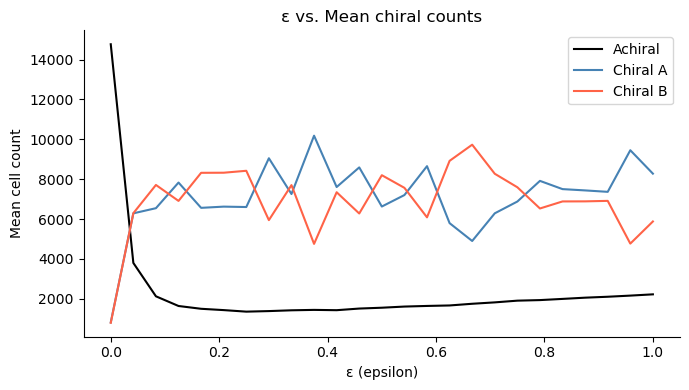

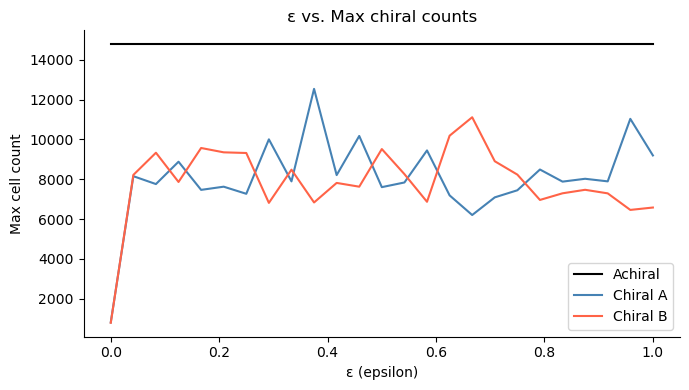

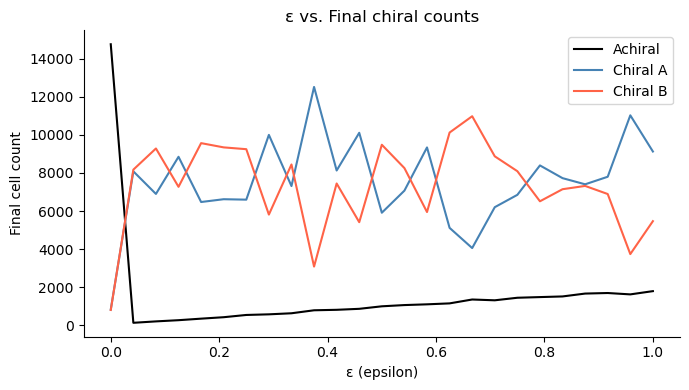

In [3]:
# Figure 1 — Epsilon vs. Mean values
fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

ax.plot(epsilons, mean_0, label='Achiral',  color='black')
ax.plot(epsilons, mean_A, label='Chiral A', color='steelblue')
ax.plot(epsilons, mean_B, label='Chiral B', color='tomato')

ax.set_xlabel('ε (epsilon)')
ax.set_ylabel('Mean cell count')
ax.set_title('ε vs. Mean chiral counts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()


# Figure 2 — Epsilon vs. Max values
fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

ax.plot(epsilons, max_0, label='Achiral',  color='black')
ax.plot(epsilons, max_A, label='Chiral A', color='steelblue')
ax.plot(epsilons, max_B, label='Chiral B', color='tomato')

ax.set_xlabel('ε (epsilon)')
ax.set_ylabel('Max cell count')
ax.set_title('ε vs. Max chiral counts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

# Figure 3 — Epsilon vs. Last value
fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

ax.plot(epsilons, last_0, label='Achiral',  color='black')
ax.plot(epsilons, last_A, label='Chiral A', color='steelblue')
ax.plot(epsilons, last_B, label='Chiral B', color='tomato')

ax.set_xlabel('ε (epsilon)')
ax.set_ylabel('Final cell count')
ax.set_title('ε vs. Final chiral counts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()


### 64

In [30]:
SWEEP_DIR = '../experiments/sweep_achiral_majority_64_eps_0.0_to_1.0_pcop0.8'
data = load_sweep_data(SWEEP_DIR)

# Extract variables for convenience
epsilons = data['epsilons']
mean_0, mean_A, mean_B = data['mean_0'], data['mean_A'], data['mean_B']
max_0, max_A, max_B = data['max_0'], data['max_A'], data['max_B']
last_0, last_A, last_B = data['last_0'], data['last_A'], data['last_B']
records = data['records']

Loaded 100 epsilon values from ../experiments/sweep_achiral_majority_64_eps_0.0_to_1.0_pcop0.8


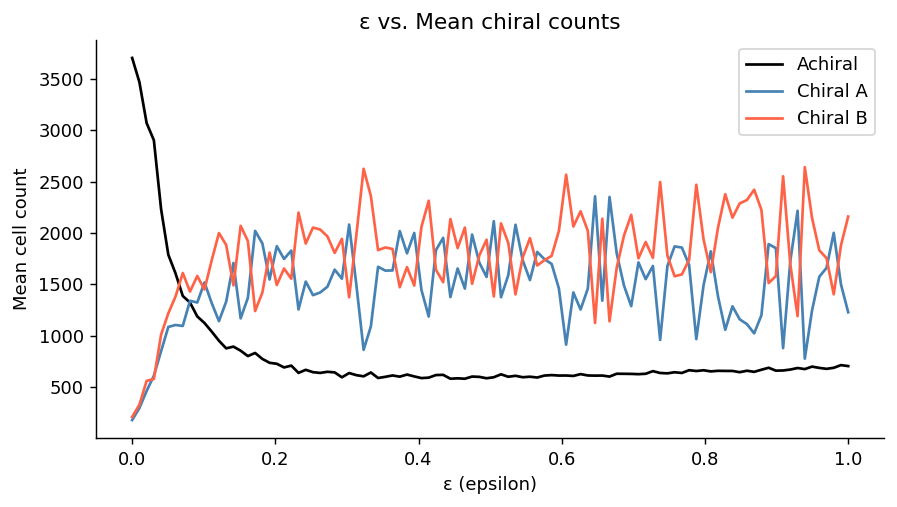

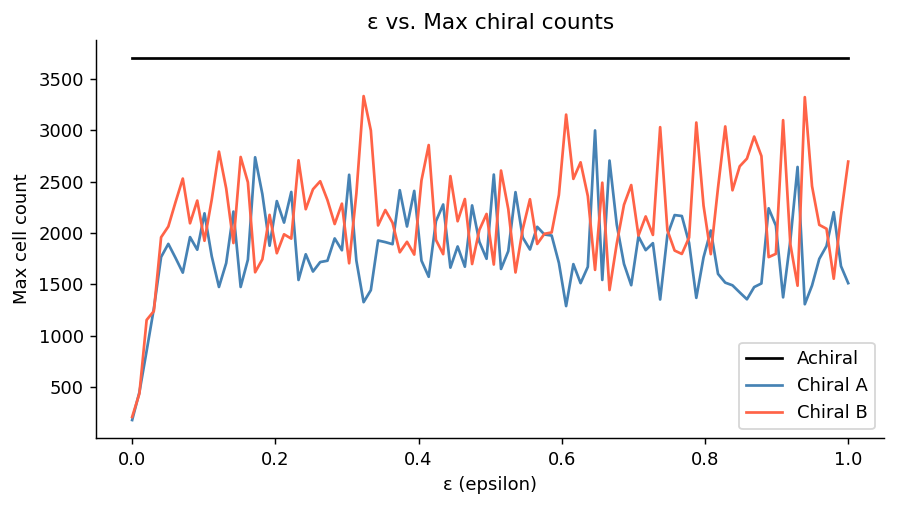

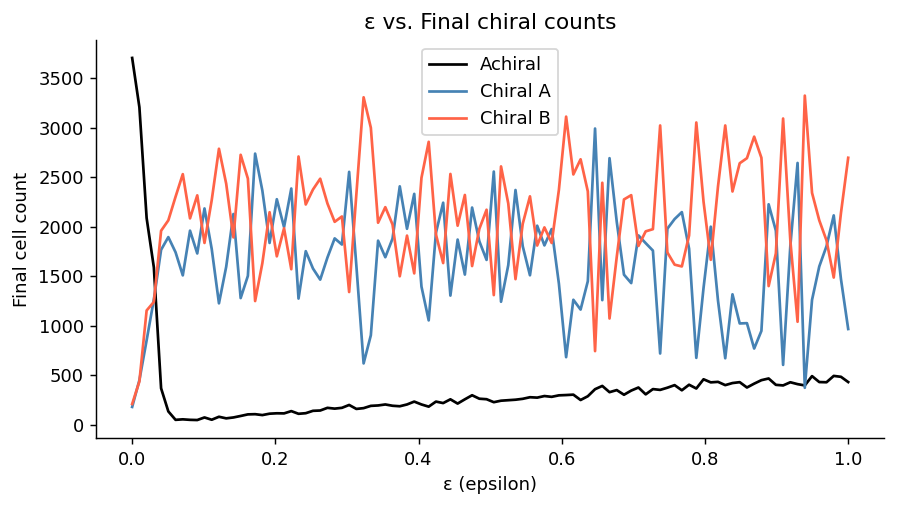

In [31]:
# Figure 1 — Epsilon vs. Mean values
fig, ax = plt.subplots(figsize=(7, 4), dpi=130)

ax.plot(epsilons, mean_0, label='Achiral',  color='black')
ax.plot(epsilons, mean_A, label='Chiral A', color='steelblue')
ax.plot(epsilons, mean_B, label='Chiral B', color='tomato')

ax.set_xlabel('ε (epsilon)')
ax.set_ylabel('Mean cell count')
ax.set_title('ε vs. Mean chiral counts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()


# Figure 2 — Epsilon vs. Max values
fig, ax = plt.subplots(figsize=(7, 4), dpi=130)

ax.plot(epsilons, max_0, label='Achiral',  color='black')
ax.plot(epsilons, max_A, label='Chiral A', color='steelblue')
ax.plot(epsilons, max_B, label='Chiral B', color='tomato')

ax.set_xlabel('ε (epsilon)')
ax.set_ylabel('Max cell count')
ax.set_title('ε vs. Max chiral counts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

# Figure 3 — Epsilon vs. Last value
fig, ax = plt.subplots(figsize=(7, 4), dpi=130)

ax.plot(epsilons, last_0, label='Achiral',  color='black')
ax.plot(epsilons, last_A, label='Chiral A', color='steelblue')
ax.plot(epsilons, last_B, label='Chiral B', color='tomato')

ax.set_xlabel('ε (epsilon)')
ax.set_ylabel('Final cell count')
ax.set_title('ε vs. Final chiral counts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()
